# 01. Data Tour: Bai, Collin-Dufresne (2019) Replication

This notebook gives a brief tour of the cleaned data and the main analysis steps
used in the replication of Figure 1 and Table 1.

In [1]:
from pathlib import Path
import pandas as pd
import plotly.express as px
from settings import config
from IPython.display import Image, display

DATA_DIR = Path(config("DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))

In [2]:
matched = pd.read_parquet(DATA_DIR / "matched_bond_cds.parquet")
pecds = pd.read_parquet(DATA_DIR / "pecds.parquet")
basis = pd.read_parquet(DATA_DIR / "basis.parquet")

for df in [matched, pecds, basis]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

## 1. Overview of cleaned data

In [3]:
print("Matched bond-CDS data:")
print(matched.shape)
print(matched.head())

Matched bond-CDS data:
(16727368, 24)
        date ticker redcode tenor currency docclause  cds_spread year_month  \
0 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
1 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
2 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
3 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
4 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   

   bond_date  issue_id  ...  coupon   maturity        tmt   price_eom  \
0 2006-07-31   21454.0  ...     9.8 2012-02-01   5.586111     116.589   
1 2006-07-31   21456.0  ...  10.125 2022-04-15  15.936111      127.27   
2 2006-07-31   21463.0  ...   7.875 2013-08-01   7.105556     109.414   
3 2006-07-31   27905.0  ...    8.75 2015-08-01   9.133333     114.739   
4 2006-07-31  123167.0  ...     8.0 2011-06-01   4.905556  109.258582   

      yield rating_class  sp_rating  sp_ig  mood

In [4]:
print("PECDS data:")
print(pecds.shape)
print(pecds.head())

PECDS data:
(16727368, 25)
        date ticker redcode tenor currency docclause  cds_spread year_month  \
0 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
1 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
2 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
3 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
4 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   

   bond_date  issue_id  ...   maturity        tmt   price_eom     yield  \
0 2006-07-31   21454.0  ... 2012-02-01   5.586111     116.589  0.062041   
1 2006-07-31   21456.0  ... 2022-04-15  15.936111      127.27  0.071951   
2 2006-07-31   21463.0  ... 2013-08-01   7.105556     109.414  0.062029   
3 2006-07-31   27905.0  ... 2015-08-01   9.133333     114.739  0.065613   
4 2006-07-31  123167.0  ... 2011-06-01   4.905556  109.258582  0.057733   

   rating_class sp_rating  sp_ig  moodys_rating

In [5]:
print("Basis data:")
print(basis.shape)
print(basis.head())

Basis data:
(16727368, 27)
        date ticker redcode tenor currency docclause  cds_spread year_month  \
0 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
1 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
2 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
3 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   
4 2006-07-03      T  001AEC    5Y      USD      XR14    0.002347    2006-07   

   bond_date  issue_id  ...   price_eom     yield rating_class  sp_rating  \
0 2006-07-31   21454.0  ...     116.589  0.062041         0.IG         NR   
1 2006-07-31   21456.0  ...      127.27  0.071951         0.IG         NR   
2 2006-07-31   21463.0  ...     109.414  0.062029         0.IG         NR   
3 2006-07-31   27905.0  ...     114.739  0.065613         0.IG         NR   
4 2006-07-31  123167.0  ...  109.258582  0.057733         0.IG         NR   

   sp_ig moodys_rating  moodys_ig  

## 2. Sample coverage

In [6]:
print("Matched sample date range:", matched["date"].min(), "to", matched["date"].max())
print("Basis sample date range:", basis["date"].min(), "to", basis["date"].max())

if "ticker" in matched.columns:
    print("Unique CDS tickers:", matched["ticker"].nunique())

if "issue_id" in matched.columns:
    print("Unique bond issues:", matched["issue_id"].nunique())

Matched sample date range: 2006-07-03 00:00:00 to 2022-03-31 00:00:00
Basis sample date range: 2006-07-03 00:00:00 to 2022-03-31 00:00:00


Unique CDS tickers: 720


Unique bond issues: 7363


## 3. Construction of PECDS

In this simplified replication, PECDS is proxied by the bond yield:

`pecds = yield`

In [7]:
pecds[["date", "yield", "pecds"]].head()

,date,yield,pecds
0,2006-07-03,0.062041,0.062041
1,2006-07-03,0.071951,0.071951
2,2006-07-03,0.062029,0.062029
3,2006-07-03,0.065613,0.065613
4,2006-07-03,0.057733,0.057733


## 4. Construction of the CDS-bond basis

The economic definition of the basis is:

`basis = cds_spread - pecds`

In the analysis scripts, the basis is then converted to basis points for reporting:

`basis_bps = 10000 * basis`

Figure 1 and Table 1 both use `basis_bps`.

In [8]:
basis[["date", "cds_spread", "pecds", "basis", "basis_bps"]].head()

,date,cds_spread,pecds,basis,basis_bps
0,2006-07-03,0.002347,0.062041,-0.059694,-596.941356
1,2006-07-03,0.002347,0.071951,-0.069604,-696.044534
2,2006-07-03,0.002347,0.062029,-0.059682,-596.824382
3,2006-07-03,0.002347,0.065613,-0.063266,-632.66338
4,2006-07-03,0.002347,0.057733,-0.055386,-553.85809


## 5. Simple time-series summary

The final analysis is reported in basis points, so the summary plots below use `basis_bps`.

In [9]:
avg_basis = basis.groupby("date", as_index=False)["basis_bps"].mean()
avg_basis.head()

,date,basis_bps
0,2006-07-03,-519.559255
1,2006-07-04,-519.57436
2,2006-07-05,-518.949408
3,2006-07-06,-519.541762
4,2006-07-07,-520.304605


In [10]:
fig = px.line(
    avg_basis,
    x="date",
    y="basis_bps",
    title="Average CDS-Bond Basis (bps) Over Time"
)
fig

## 6. IG vs HY comparison

In [11]:
ig_hy = basis.groupby(["date", "rating_class"], as_index=False)["basis_bps"].median()
fig = px.line(
    ig_hy,
    x="date",
    y="basis_bps",
    color="rating_class",
    title="Median CDS-Bond Basis (bps) by Rating Class"
)
fig

## 7. Final outputs

The scripts `replicate_figure1.py` and `replicate_table1.py` generate the final
paper-style outputs used in the report:

- Figure 1: basis dispersion over paper sample for IG and HY bonds, using `basis_bps`
- Figure 2: Fig. 1 with extended time period
- Table: summary statistics across rating categories for paper crisis phases + extension, using `basis_bps`

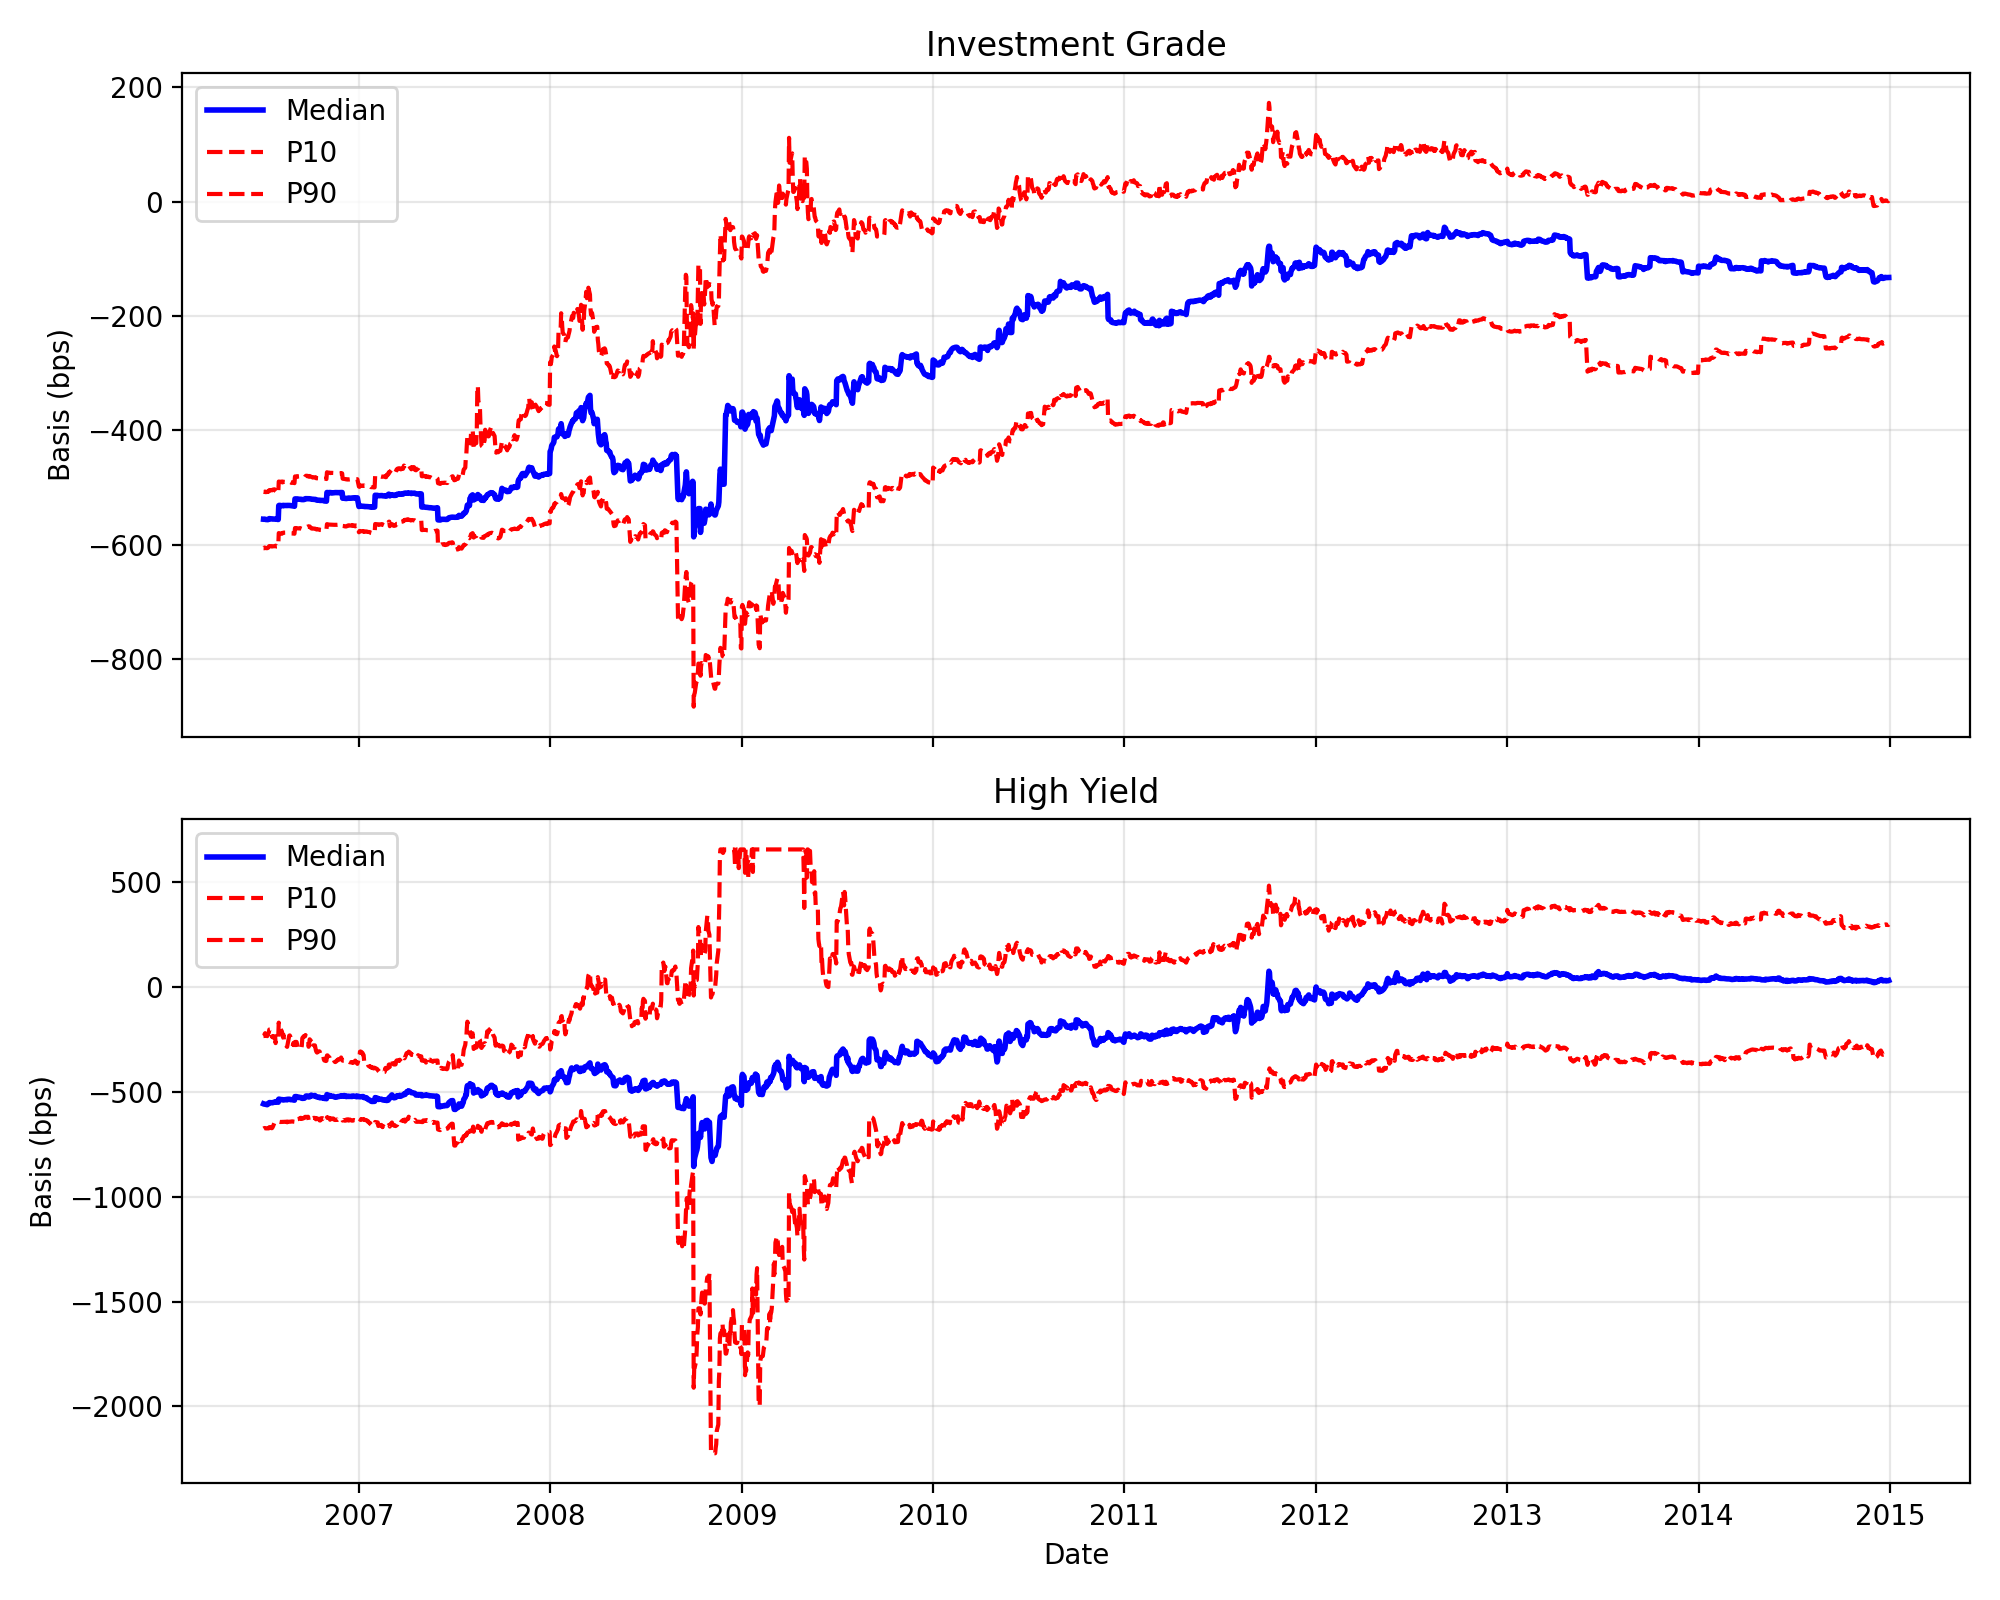

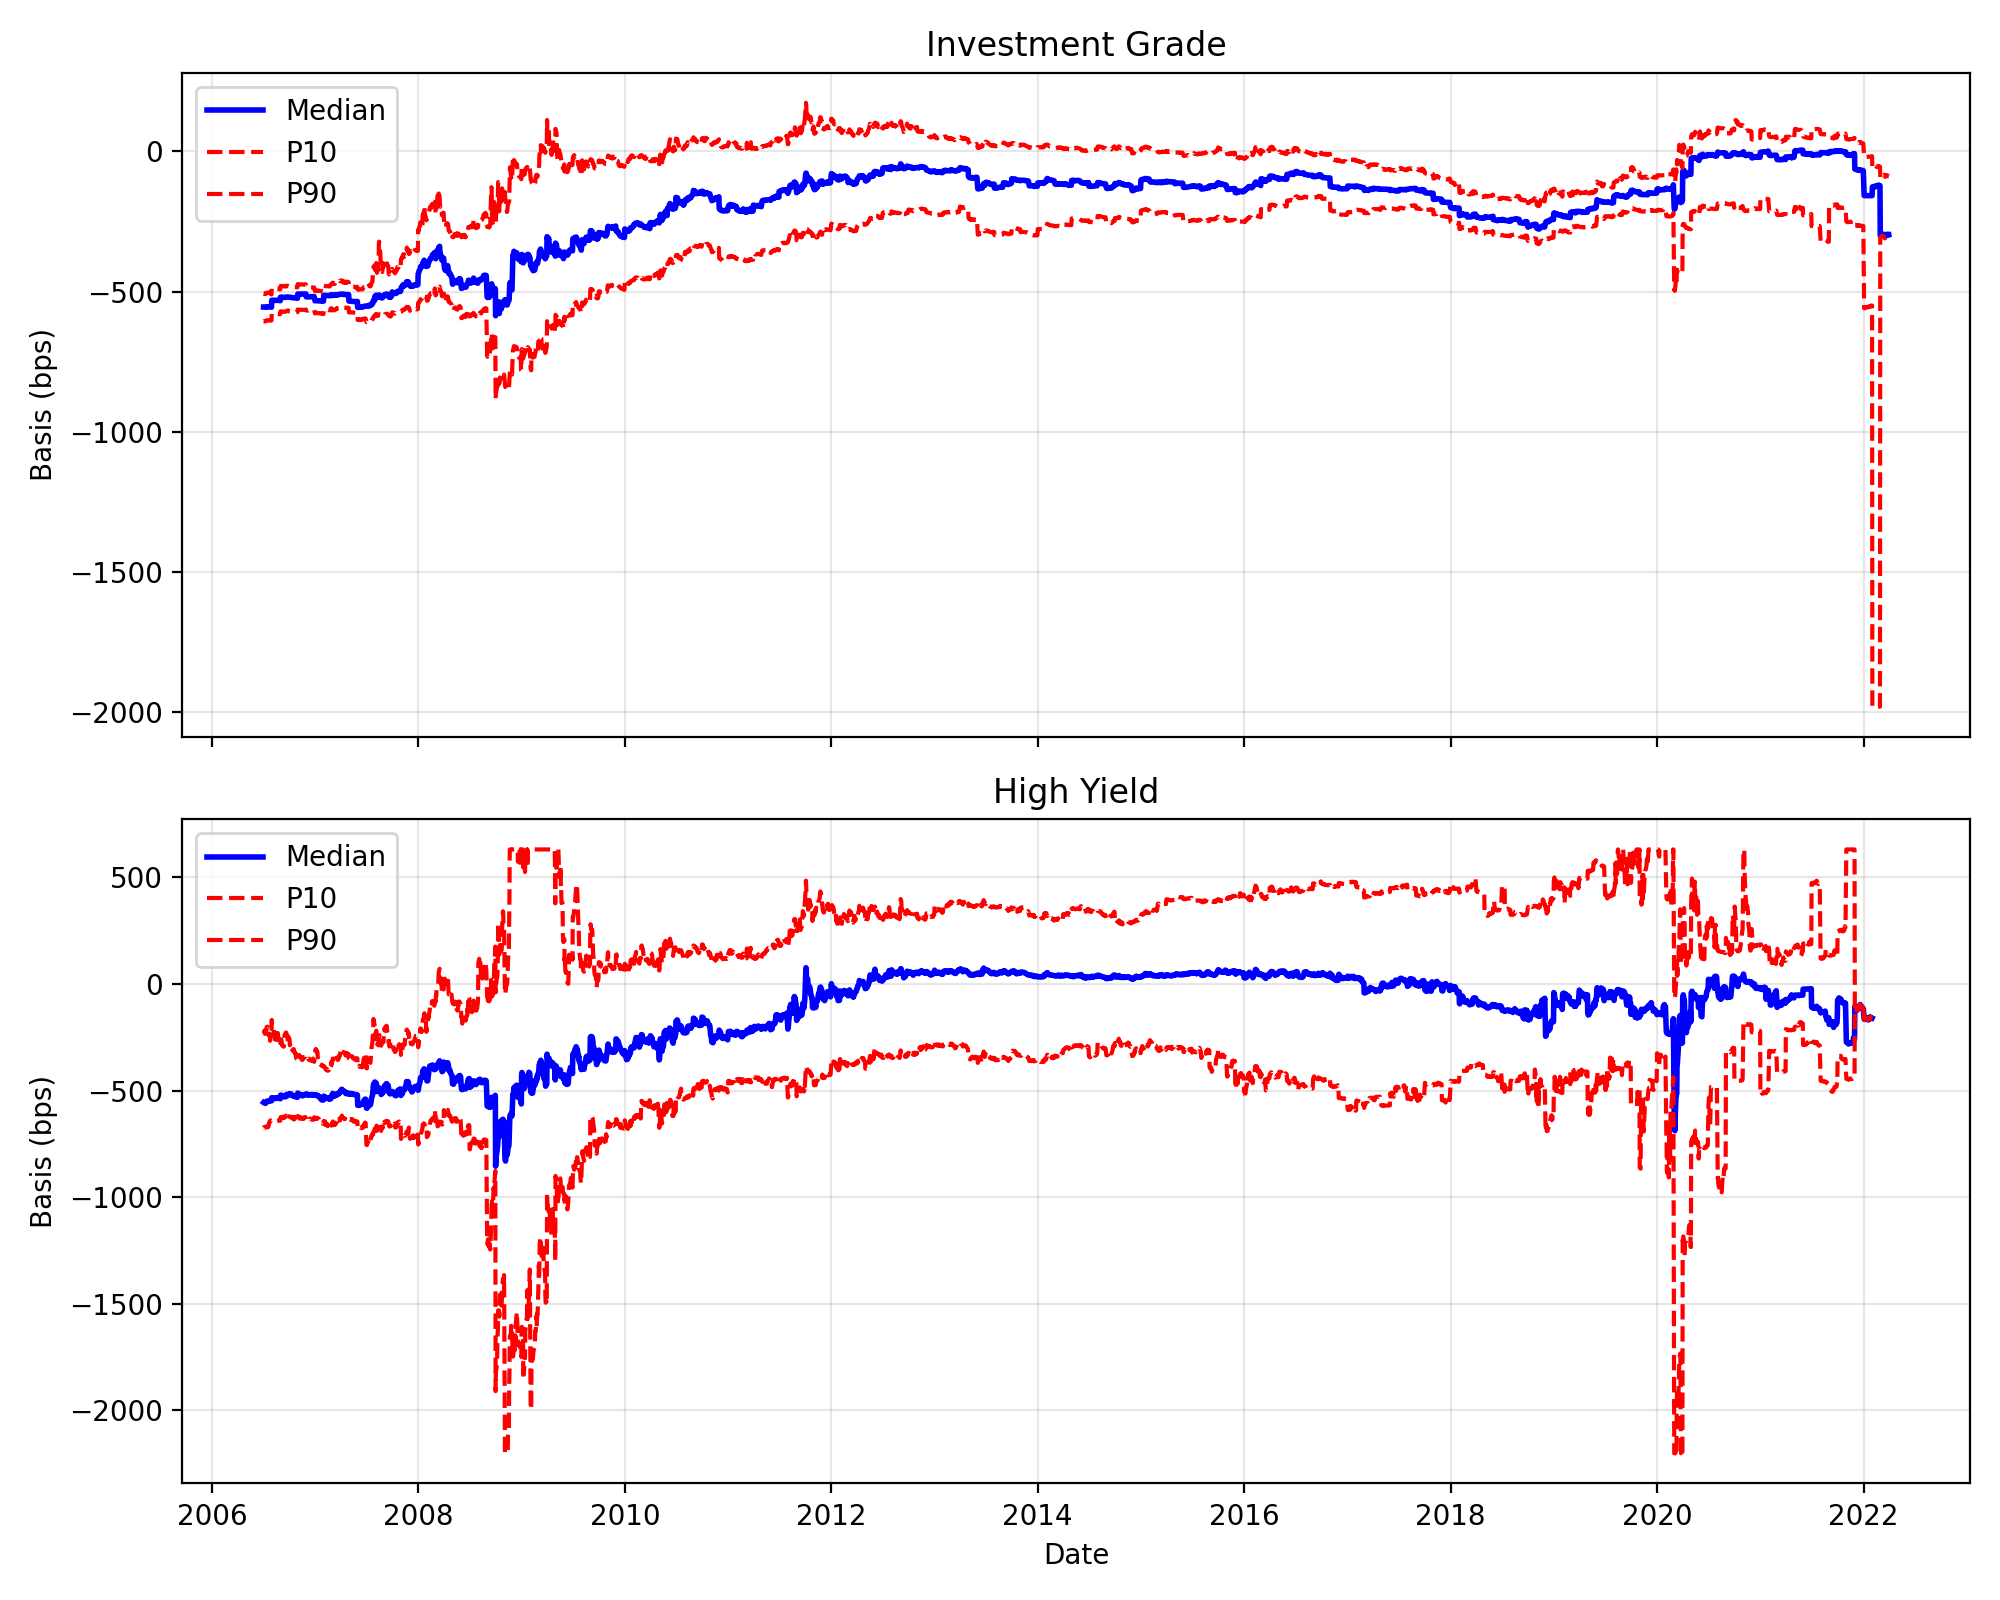

,Category,Before Crisis_Mean,Before Crisis_SD,Before Crisis_P10,Before Crisis_P90,Crisis I_Mean,Crisis I_SD,Crisis I_P10,Crisis I_P90,Crisis II_Mean,...,Crisis II_P10,Crisis II_P90,Post-crisis_Mean,Post-crisis_SD,Post-crisis_P10,Post-crisis_P90,Extended_Mean,Extended_SD,Extended_P10,Extended_P90
0,ALL,-499,188,-592,-424,-430,256,-587,-245,-405,...,-802,12,-133,338,-330,120,-128,376,-277,89
1,IG,-498,170,-574,-484,-422,212,-560,-318,-404,...,-661,-74,-151,275,-306,32,-143,194,-257,-39
2,HY,-501,213,-643,-324,-444,314,-683,-164,-403,...,-1255,681,-98,423,-411,264,-69,635,-466,395
3,AAA/AA,-129,300,-521,240,15,315,-448,401,-239,...,-789,327,-266,519,-622,94,-163,0,-163,-163
4,A,-301,366,-540,178,-232,331,-484,251,-298,...,-567,-6,-205,374,-466,24,-121,103,-219,5
5,BBB,-521,63,-568,-489,-467,93,-570,-378,-394,...,-689,-110,-190,210,-448,45,-154,71,-244,-83
6,BB,-536,140,-694,-328,-477,190,-698,-277,-28,...,-1258,1789,-98,102,-230,16,-175,29,-204,-146
7,B,-458,225,-641,-237,-435,203,-634,-213,19,...,-1721,1685,-114,211,-364,131,-1115,0,-1115,-1115
8,CCC,-510,155,-662,-379,-143,399,-528,427,-197,...,-2217,1721,130,537,-595,529,-4236,0,-4236,-4236


In [12]:
display(Image(filename=OUTPUT_DIR / "replication_figure1.png"))
display(Image(filename=OUTPUT_DIR / "extension_figure1.png"))

table1 = pd.read_csv(OUTPUT_DIR / "table1_replication.csv")
table1